In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.IFLiLiu.weights_fns import get_IF_weights
from aif360.algorithms.preprocessing.optim_preproc_helpers.data_preproc_functions import load_preproc_data_adult
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
privileged_groups = [{'sex': 1}]
unprivileged_groups = [{'sex': 0}]
dataset_orig = load_preproc_data_adult(['sex'])

In [4]:
X = dataset_orig.features
y = dataset_orig.labels.ravel()
S = dataset_orig.protected_attributes.ravel()

In [5]:
X.shape, y.shape, S.shape

((48842, 18), (48842,), (48842,))

In [6]:
x_train, x_test, y_train, y_test, s_train, s_test = train_test_split(X, y, S, test_size=0.15, random_state=42)

x_train, x_val, y_train, y_val, s_train, s_val = train_test_split(x_train, y_train, s_train, test_size=0.1765, random_state=42)

In [7]:
x_train.shape, x_val.shape, x_test.shape

((34187, 18), (7328, 18), (7327, 18))

Adult: LogReg - EOP: β = 0.5, γ = 0.2

Compas: LogReg - EOP: β = 0.2, γ = 0.1

German.: LogReg - EOP: β = 0.0, γ = 0.0

In [54]:
metric = 'eop'

seed = 42

l2_reg = 2.26220
alpha = 0.02
beta = 0.5
gamma = 0.2

In [55]:
w = get_IF_weights(x_train, y_train, x_val, y_val, s_val,
                   metric,
                   l2_reg, seed, alpha, beta, gamma)

Maximum fairness promotion: -1.29119; Maximum utility promotion: -83.42304;
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2 rows, 34187 columns and 68374 nonzeros
Model fingerprint: 0x014bd9c2
Coefficient statistics:
  Matrix range     [3e-08, 1e-01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-01, 2e+01]
Presolve removed 0 rows and 33881 columns
Presolve time: 0.05s
Presolved: 2 rows, 306 columns, 612 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   3.010968e+01   0.000000e+00      0s
       5    2.1434538e+03   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.09 seconds (0.02 work units)
Optimal objective  2.143453770e+03
Total removal: 2143.45377; Ratio: 6.270%



In [56]:
unique, counts  = np.unique(w, return_counts=True)
np.asarray((unique, counts)).T

array([[0.00000000e+00, 2.14200000e+03],
       [2.12228591e-01, 1.00000000e+00],
       [3.34001664e-01, 1.00000000e+00],
       [1.00000000e+00, 3.20430000e+04]])

In [57]:
import matplotlib.pyplot as plt

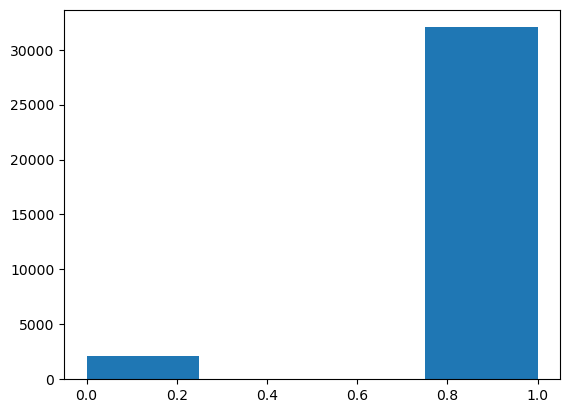

In [58]:
_ = plt.hist(w, bins=len(np.unique(w)))